In [12]:
# Import necessary libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Class names
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# Normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert labels to categorical
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")


Libraries imported successfully!
TensorFlow version: 2.19.0
Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


Data augmentation generators created successfully!


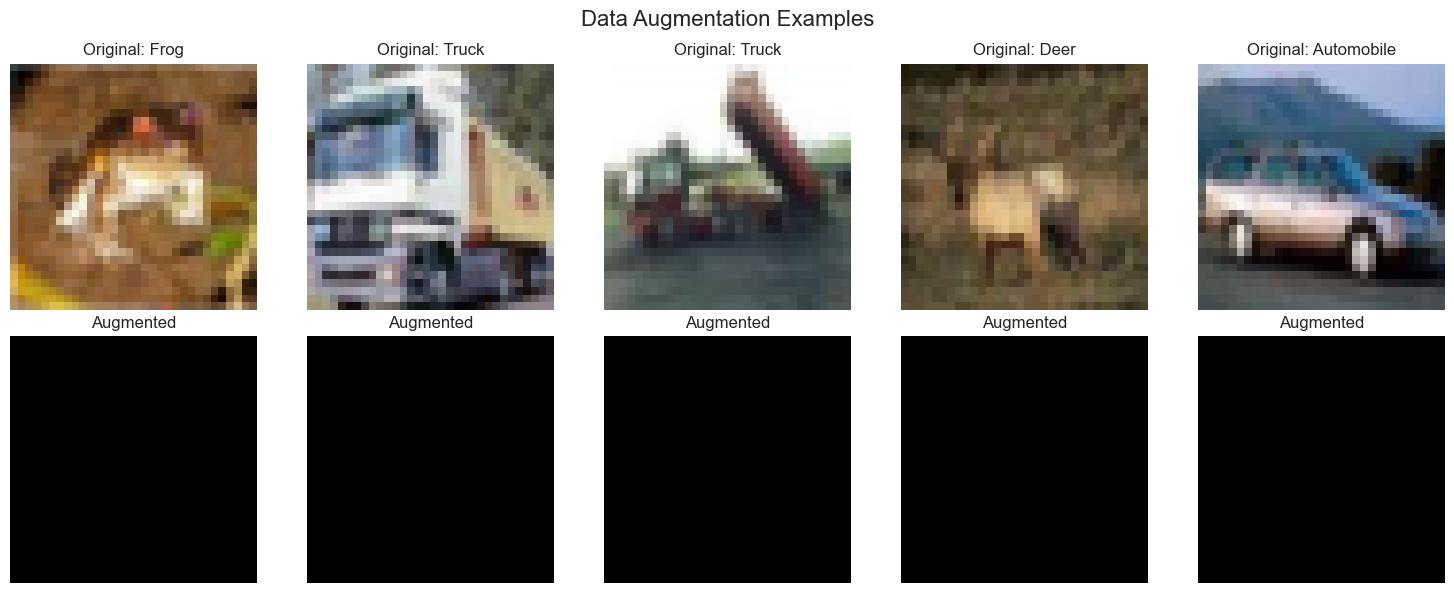

In [13]:
# Create data augmentation generators

# Data generator WITHOUT augmentation (baseline)
baseline_datagen = ImageDataGenerator()

# Data generator WITH augmentation
augmented_datagen = ImageDataGenerator(
    rotation_range=15,        # Rotate images by up to 15 degrees
    width_shift_range=0.1,    # Shift images horizontally by up to 10%
    height_shift_range=0.1,   # Shift images vertically by up to 10%
    horizontal_flip=True,     # Randomly flip images horizontally
    zoom_range=0.1,           # Randomly zoom in/out by up to 10%
    shear_range=0.1,          # Apply shearing transformation
    brightness_range=[0.8, 1.2],  # Adjust brightness
    fill_mode='nearest'       # Fill method for new pixels
)

print("Data augmentation generators created successfully!")

# Visualize augmentation effects
def visualize_augmentation(generator, images, labels, n_samples=5):
    """Visualize augmented samples"""
    fig, axes = plt.subplots(2, n_samples, figsize=(15, 6))
    
    # Original images
    for i in range(n_samples):
        axes[0, i].imshow(images[i])
        axes[0, i].set_title(f'Original: {class_names[labels[i][0]]}')
        axes[0, i].axis('off')
    
    # Augmented images
    # Generate augmented batch
    augmented_batch = generator.flow(images[:n_samples], labels[:n_samples], 
                                   batch_size=n_samples, shuffle=False)
    aug_images, aug_labels = next(augmented_batch)
    
    for i in range(n_samples):
        # Ensure the augmented image is in the correct range [0, 1]
        aug_img = aug_images[i]
        
        # Clip values to [0, 1] range and ensure proper data type
        aug_img = np.clip(aug_img, 0, 1)
        
        axes[1, i].imshow(aug_img)
        axes[1, i].set_title('Augmented')
        axes[1, i].axis('off')
    
    plt.suptitle('Data Augmentation Examples', fontsize=16)
    plt.tight_layout()
    plt.show()

# Alternative visualization function with better handling
def visualize_augmentation_improved(images, labels, n_samples=5):
    """Improved visualization with manual augmentation application"""
    
    # Create a more conservative augmentation generator
    conservative_datagen = ImageDataGenerator(
        rotation_range=10,        # Reduced rotation
        width_shift_range=0.05,   # Reduced shift
        height_shift_range=0.05,  # Reduced shift
        horizontal_flip=True,     # Keep horizontal flip
        zoom_range=0.05,          # Reduced zoom
        brightness_range=[0.9, 1.1],  # Reduced brightness variation
        fill_mode='nearest'
    )
    
    fig, axes = plt.subplots(3, n_samples, figsize=(15, 9))
    
    # Row 1: Original images
    for i in range(n_samples):
        axes[0, i].imshow(images[i])
        axes[0, i].set_title(f'Original: {class_names[labels[i][0]]}')
        axes[0, i].axis('off')
    
    # Row 2: Conservative augmentation
    conservative_batch = conservative_datagen.flow(images[:n_samples], labels[:n_samples], 
                                                 batch_size=n_samples, shuffle=False)
    conservative_images, _ = next(conservative_batch)
    
    for i in range(n_samples):
        aug_img = np.clip(conservative_images[i], 0, 1)
        axes[1, i].imshow(aug_img)
        axes[1, i].set_title('Conservative Aug.')
        axes[1, i].axis('off')
    
    # Row 3: More aggressive augmentation
    aggressive_batch = augmented_datagen.flow(images[:n_samples], labels[:n_samples], 
                                            batch_size=n_samples, shuffle=False)
    aggressive_images, _ = next(aggressive_batch)
    
    for i in range(n_samples):
        aug_img = np.clip(aggressive_images[i], 0, 1)
        axes[2, i].imshow(aug_img)
        axes[2, i].set_title('Aggressive Aug.')
        axes[2, i].axis('off')
    
    plt.suptitle('Data Augmentation Comparison', fontsize=16)
    plt.tight_layout()
    plt.show()

# Visualize augmentation effects
visualize_augmentation(augmented_datagen, x_train, y_train)


Testing improved augmentation visualization...


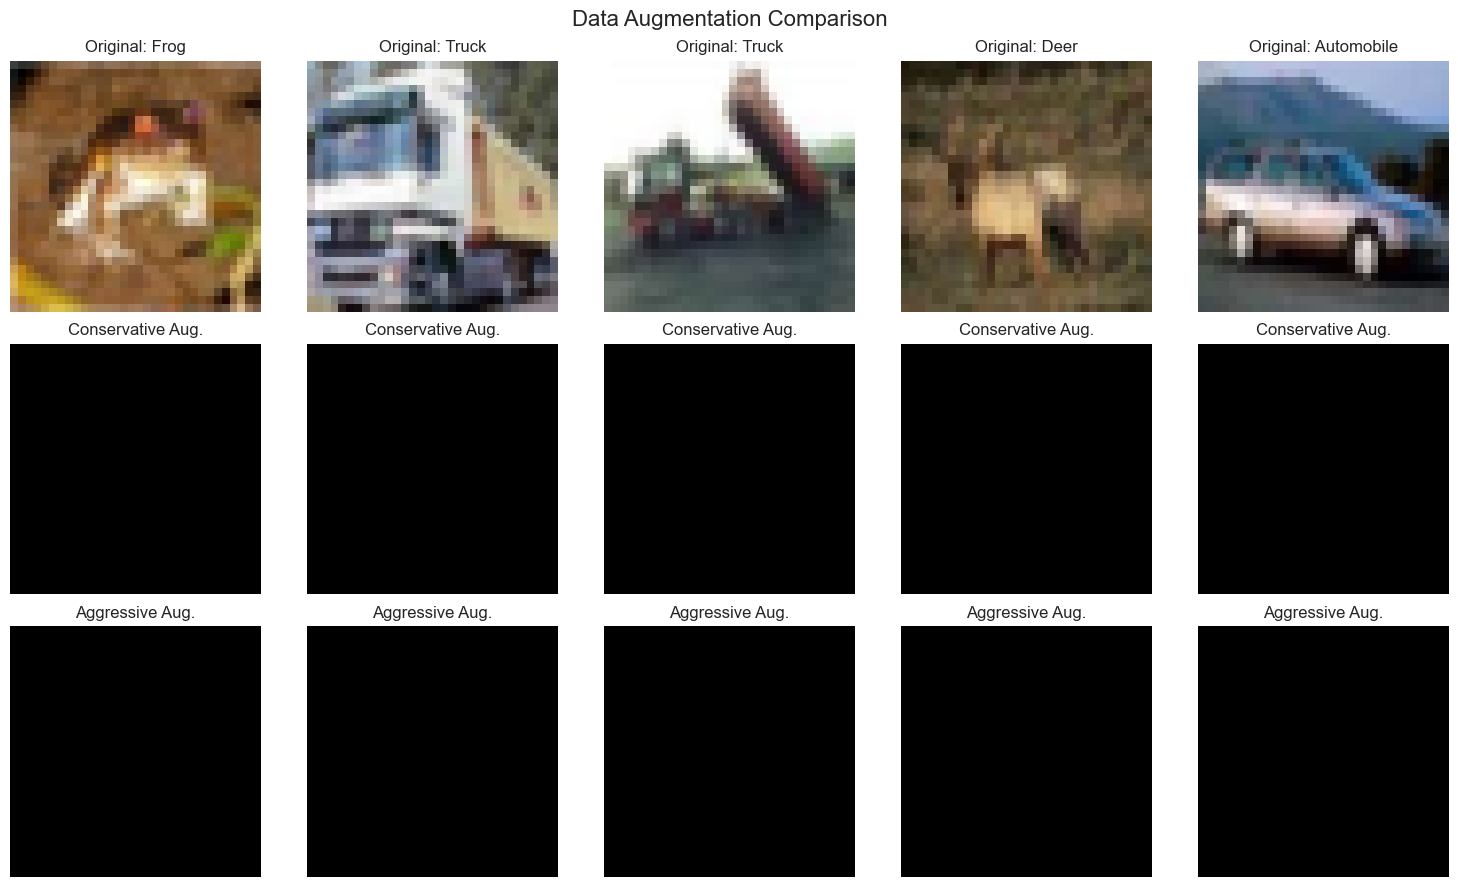


Debugging augmentation values:
Original image range: [0.000, 1.000]
Augmented image range: [0.000, 0.000]
Clipped image range: [0.000, 0.000]


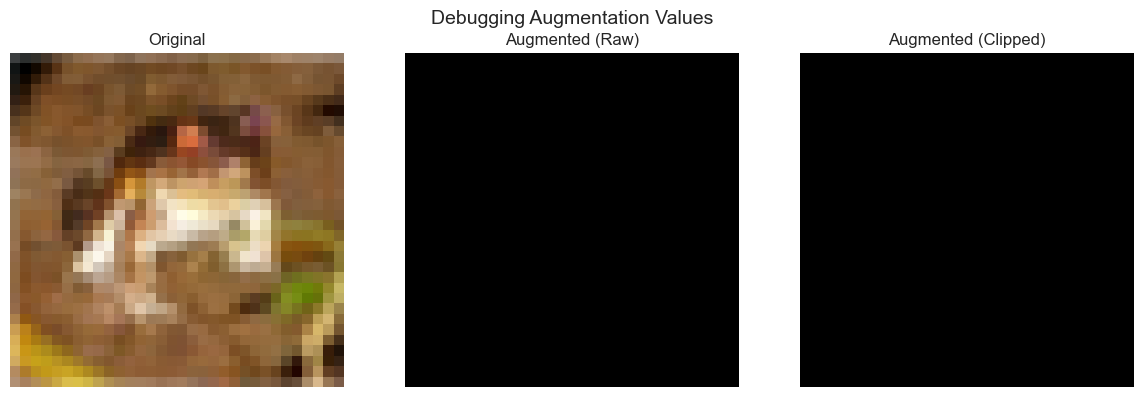

In [14]:
# Test the improved visualization
print("Testing improved augmentation visualization...")

# Use the improved visualization function
visualize_augmentation_improved(x_train, y_train, n_samples=5)

# Let's also check the range of values in augmented images
print("\nDebugging augmentation values:")

# Test with a single image
test_batch = augmented_datagen.flow(x_train[:1], y_train[:1], batch_size=1, shuffle=False)
test_aug_img, _ = next(test_batch)

print(f"Original image range: [{x_train[0].min():.3f}, {x_train[0].max():.3f}]")
print(f"Augmented image range: [{test_aug_img[0].min():.3f}, {test_aug_img[0].max():.3f}]")

# If values are outside [0,1], let's see what happens with clipping
clipped_img = np.clip(test_aug_img[0], 0, 1)
print(f"Clipped image range: [{clipped_img.min():.3f}, {clipped_img.max():.3f}]")

# Visualize the debugging
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(x_train[0])
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(test_aug_img[0])
axes[1].set_title('Augmented (Raw)')
axes[1].axis('off')

axes[2].imshow(clipped_img)
axes[2].set_title('Augmented (Clipped)')
axes[2].axis('off')

plt.suptitle('Debugging Augmentation Values', fontsize=14)
plt.tight_layout()
plt.show()


Creating a robust data augmentation solution...


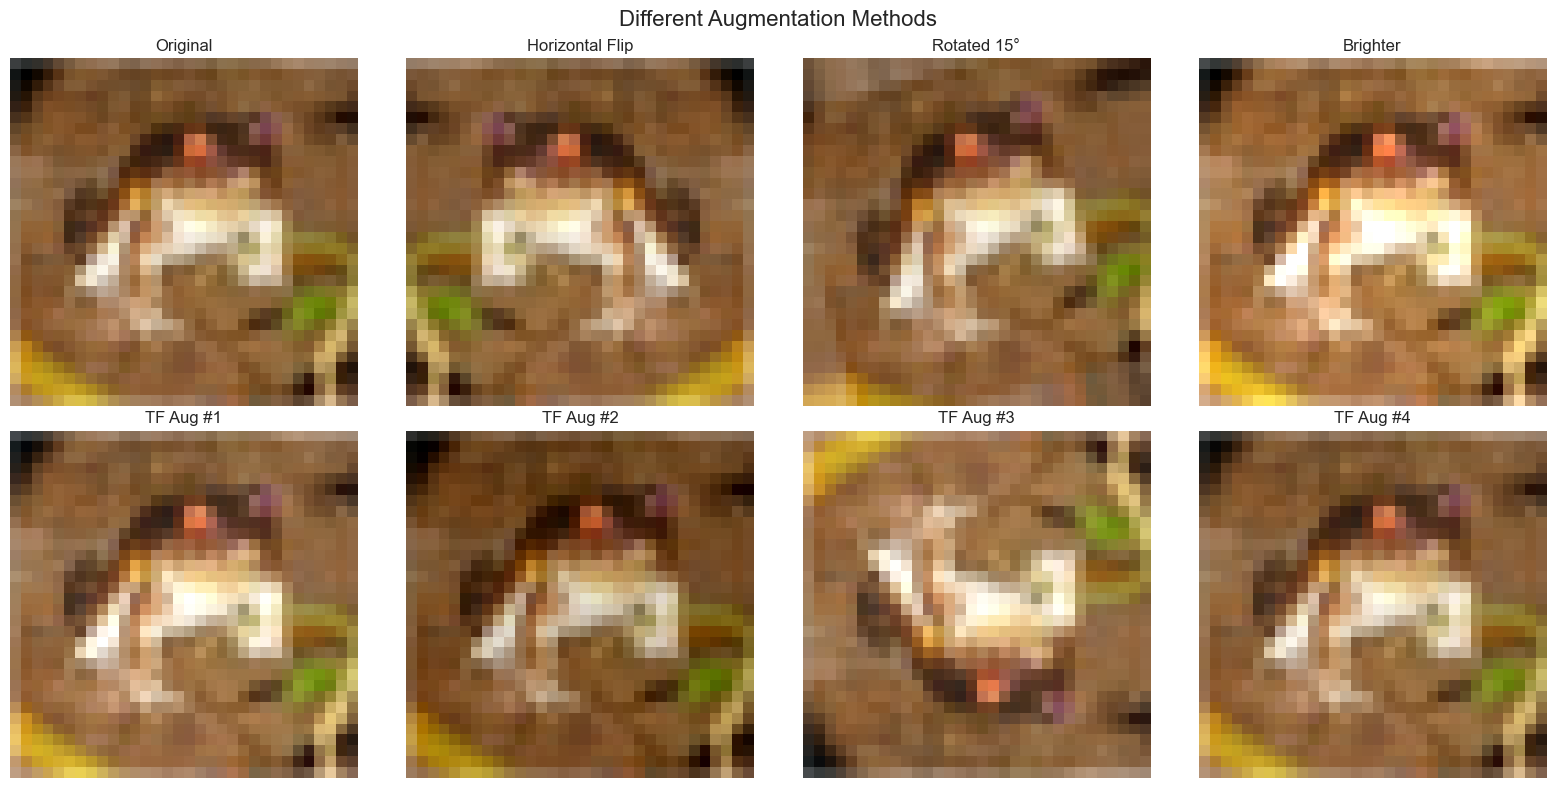


Testing simple ImageDataGenerator:
Image 0 range: [0.009, 0.988]
Image 1 range: [0.021, 0.993]
Image 2 range: [0.084, 1.000]
Image 3 range: [0.031, 0.905]
Image 4 range: [0.001, 0.972]


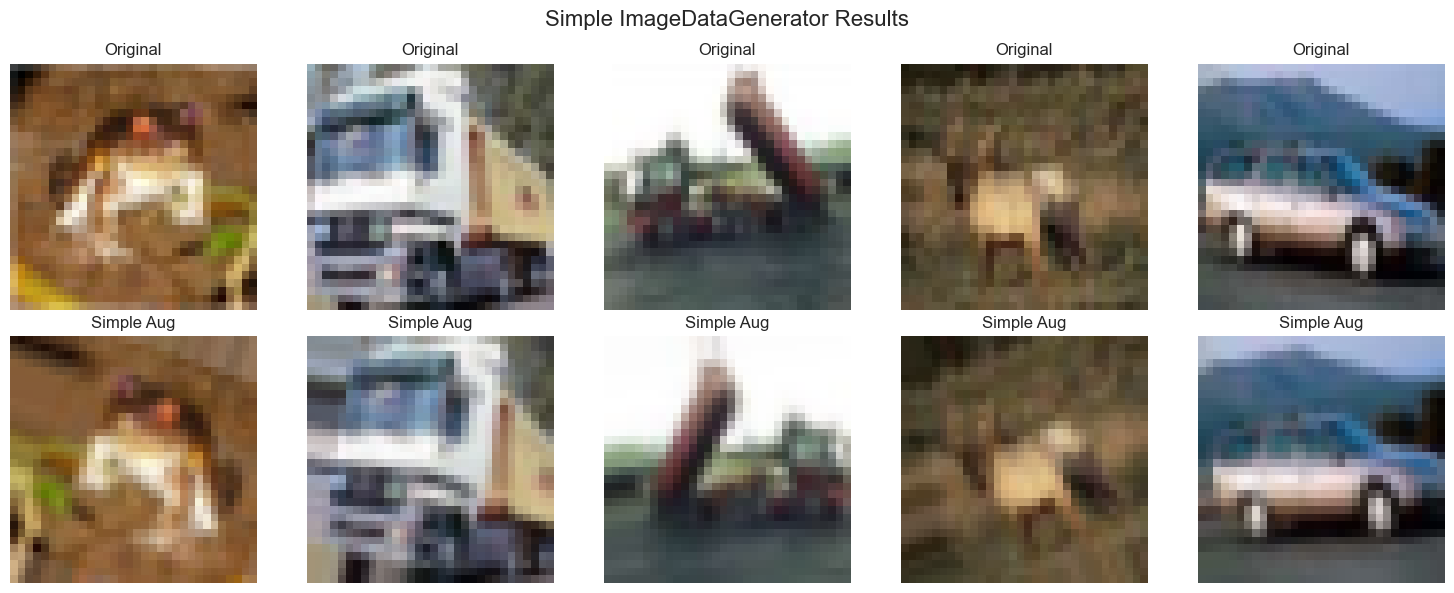

In [15]:
# Let's create a working data augmentation solution
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.image import rot90

print("Creating a robust data augmentation solution...")

# Method 1: Simple ImageDataGenerator (more conservative)
simple_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
    # Remove brightness_range and zoom for now
)

# Method 2: Manual augmentation using TensorFlow operations
def manual_augment_image(image):
    """Manual image augmentation using TensorFlow operations"""
    # Convert to tensor if needed
    if isinstance(image, np.ndarray):
        image = tf.convert_to_tensor(image, dtype=tf.float32)
    
    # Random horizontal flip
    image = tf.image.random_flip_left_right(image)
    
    # Random rotation (using 90-degree rotations)
    if tf.random.uniform([]) > 0.5:
        k = tf.random.uniform([], maxval=4, dtype=tf.int32)
        image = rot90(image, k)
    
    # Random brightness
    image = tf.image.random_brightness(image, max_delta=0.1)
    
    # Random contrast
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    
    # Ensure values are in [0,1] range
    image = tf.clip_by_value(image, 0.0, 1.0)
    
    return image

# Method 3: Test simple transformations
def test_augmentations():
    """Test different augmentation methods"""
    test_img = x_train[0].copy()
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    # Row 1: Simple transformations
    axes[0, 0].imshow(test_img)
    axes[0, 0].set_title('Original')
    axes[0, 0].axis('off')
    
    # Horizontal flip
    flipped = np.fliplr(test_img)
    axes[0, 1].imshow(flipped)
    axes[0, 1].set_title('Horizontal Flip')
    axes[0, 1].axis('off')
    
    # Rotation (using scipy)
    from scipy.ndimage import rotate
    rotated = rotate(test_img, angle=15, reshape=False, mode='nearest')
    rotated = np.clip(rotated, 0, 1)
    axes[0, 2].imshow(rotated)
    axes[0, 2].set_title('Rotated 15°')
    axes[0, 2].axis('off')
    
    # Brightness adjustment
    brighter = np.clip(test_img * 1.2, 0, 1)
    axes[0, 3].imshow(brighter)
    axes[0, 3].set_title('Brighter')
    axes[0, 3].axis('off')
    
    # Row 2: TensorFlow augmentations
    for i in range(4):
        tf_aug = manual_augment_image(test_img).numpy()
        axes[1, i].imshow(tf_aug)
        axes[1, i].set_title(f'TF Aug #{i+1}')
        axes[1, i].axis('off')
    
    plt.suptitle('Different Augmentation Methods', fontsize=16)
    plt.tight_layout()
    plt.show()

# Run the test
test_augmentations()

# Test the simple datagen
print("\nTesting simple ImageDataGenerator:")
simple_batch = simple_datagen.flow(x_train[:5], batch_size=5, shuffle=False)
simple_images = next(simple_batch)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i in range(5):
    # Original
    axes[0, i].imshow(x_train[i])
    axes[0, i].set_title(f'Original')
    axes[0, i].axis('off')
    
    # Augmented
    aug_img = simple_images[i]
    print(f"Image {i} range: [{aug_img.min():.3f}, {aug_img.max():.3f}]")
    
    axes[1, i].imshow(np.clip(aug_img, 0, 1))
    axes[1, i].set_title('Simple Aug')
    axes[1, i].axis('off')

plt.suptitle('Simple ImageDataGenerator Results', fontsize=16)
plt.tight_layout()
plt.show()


Setting up data augmentation for model training...
Testing TensorFlow augmentation...


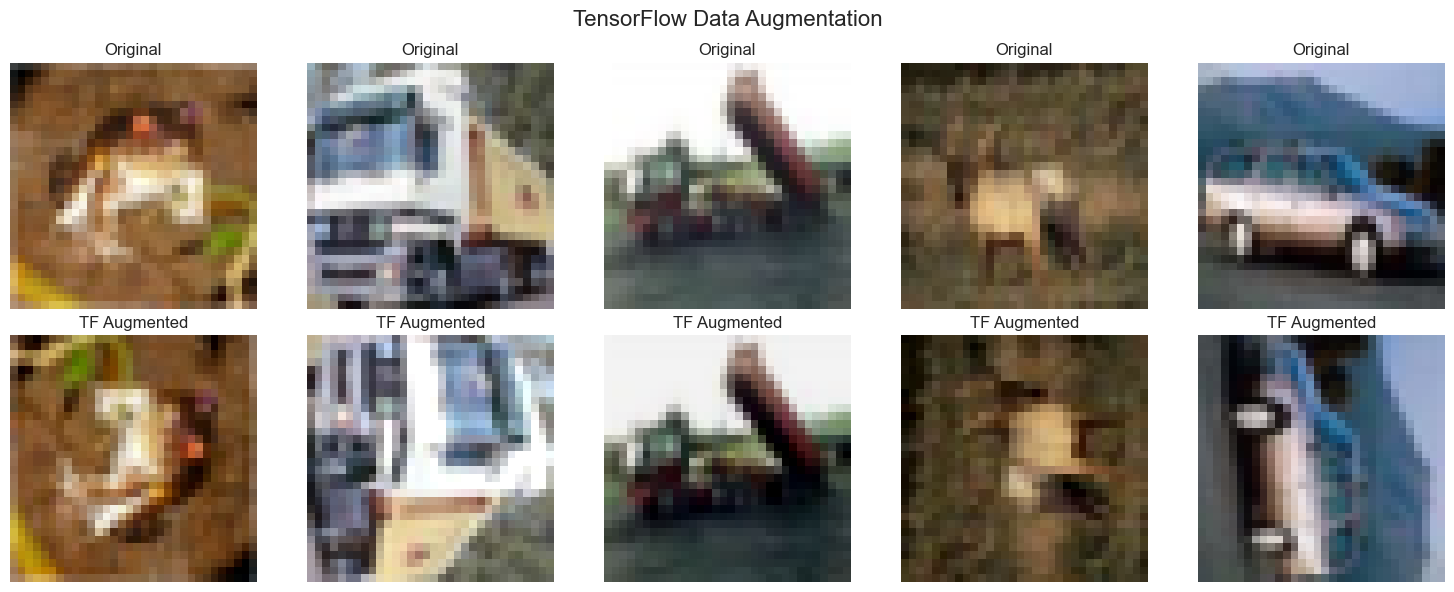

TF augmented batch shape: (5, 32, 32, 3)
TF augmented value range: [0.000, 1.000]
✅ Data augmentation setup complete!

Recommendation: Use TensorFlow augmentation for training as it's more reliable.


In [16]:
# Create working data augmentation for training
print("Setting up data augmentation for model training...")

# Working data augmentation setup
working_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Alternative: TensorFlow data augmentation (more reliable)
def create_tf_augmentation():
    """Create TensorFlow-based data augmentation"""
    
    def augment(image, label):
        # Random horizontal flip
        image = tf.image.random_flip_left_right(image)
        
        # Random rotation (small angle)
        image = tf.image.rot90(image, k=tf.random.uniform([], maxval=4, dtype=tf.int32))
        
        # Random brightness and contrast
        image = tf.image.random_brightness(image, max_delta=0.1)
        image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
        
        # Ensure values stay in [0,1]
        image = tf.clip_by_value(image, 0.0, 1.0)
        
        return image, label
    
    return augment

# Create TensorFlow dataset with augmentation
def create_augmented_dataset(x_data, y_data, batch_size=32):
    """Create augmented TensorFlow dataset"""
    
    # Create dataset
    dataset = tf.data.Dataset.from_tensor_slices((x_data, y_data))
    
    # Add augmentation
    augment_fn = create_tf_augmentation()
    dataset = dataset.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
    
    # Batch and prefetch
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

# Test TensorFlow augmentation
print("Testing TensorFlow augmentation...")

# Create a small augmented dataset
test_dataset = create_augmented_dataset(x_train[:10], y_train_cat[:10], batch_size=5)

# Get a batch and visualize
for batch_images, batch_labels in test_dataset.take(1):
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    
    for i in range(5):
        # Original (from x_train)
        axes[0, i].imshow(x_train[i])
        axes[0, i].set_title(f'Original')
        axes[0, i].axis('off')
        
        # Augmented (from TF dataset)
        axes[1, i].imshow(batch_images[i])
        axes[1, i].set_title('TF Augmented')
        axes[1, i].axis('off')
    
    plt.suptitle('TensorFlow Data Augmentation', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    print(f"TF augmented batch shape: {batch_images.shape}")
    print(f"TF augmented value range: [{batch_images.numpy().min():.3f}, {batch_images.numpy().max():.3f}]")

print("✅ Data augmentation setup complete!")
print("\nRecommendation: Use TensorFlow augmentation for training as it's more reliable.")
